In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import random
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
print("All libraries successfully imported")

with_mask_count = len(os.listdir("dataset/with_mask"))
without_mask_count = len(os.listdir("dataset/without_mask"))
print(f"with_mask images: {with_mask_count}")
print(f"without_mask images: {without_mask_count}")


All libraries successfully imported
with_mask images: 3725
without_mask images: 3828


In [2]:
# Define paths
DATASET_PATH = "dataset"
CATEGORIES = ["with_mask", "without_mask"]
IMG_SIZE = 100

data = []
labels = []

for category in CATEGORIES:
    path = os.path.join(DATASET_PATH, category)
    label = CATEGORIES.index(category)
    
    count = 0
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:  # skip corrupted images
            continue
            
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(label)
        count += 1
    
    print(f"{category}: loaded {count} images, label={label}")

print(f"\nTotal images loaded: {len(data)}")
print(f"Total labels: {len(labels)}")

import collections
print(f"Label distribution: {collections.Counter(labels)}")

with_mask: loaded 3725 images, label=0
without_mask: loaded 3828 images, label=1

Total images loaded: 7553
Total labels: 7553
Label distribution: Counter({1: 3828, 0: 3725})


In [3]:
data = np.array(data)/255.0
labels=np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print(f"Training samplels: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")

Training samplels: 6042
Testing samples: 1511
Image shape: (100, 100, 3)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model=Sequential([
    Conv2D(32,(3,3), activation='relu',input_shape=(100,100,3)),MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu',input_shape=(100,100,3)),MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu',input_shape=(100,100,3)),MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 49, 49, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 23, 23, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 21, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 10, 10, 128)      

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
metrics=['accuracy']
)

history=model.fit(
    X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32
)



Epoch 1/10


189/189 [==============================] - 25s 125ms/step - loss: 0.3500 - accuracy: 0.8534 - val_loss: 0.2118 - val_accuracy: 0.9173
Epoch 2/10
189/189 [==============================] - 20s 107ms/step - loss: 0.2315 - accuracy: 0.9129 - val_loss: 0.1975 - val_accuracy: 0.9332
Epoch 3/10
189/189 [==============================] - 21s 110ms/step - loss: 0.1832 - accuracy: 0.9303 - val_loss: 0.1470 - val_accuracy: 0.9471
Epoch 4/10
189/189 [==============================] - 21s 109ms/step - loss: 0.1487 - accuracy: 0.9446 - val_loss: 0.1612 - val_accuracy: 0.9378
Epoch 5/10
189/189 [==============================] - 22s 116ms/step - loss: 0.1296 - accuracy: 0.9532 - val_loss: 0.1298 - val_accuracy: 0.9530
Epoch 6/10
189/189 [==============================] - 21s 111ms/step - loss: 0.1030 - accuracy: 0.9636 - val_loss: 0.1285 - val_accuracy: 0.9563
Epoch 7/10
189/189 [==============================] - 21s 113ms/step - loss: 0.0806 - accuracy: 0.9734 - val_loss: 0.1436 - val

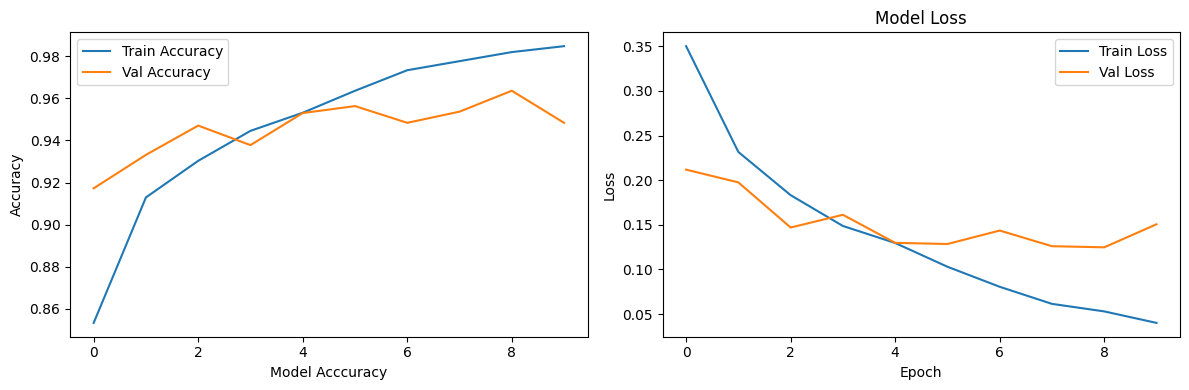

Graphs saved!


In [6]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Model Acccuracy')
plt.ylabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_results.png')  
plt.show()
print("Graphs saved!")

In [7]:
import os

os.makedirs("model", exist_ok=True)

model.save("model/mask_detector.h5")
print("Model saved successfully")
print(f"Model size: {os.path.getsize('model/mask_detector.h5')/1024/1024:.2f} MB")

Model saved successfully
Model size: 19.87 MB


C:\Users\CHHAVI MISHRA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


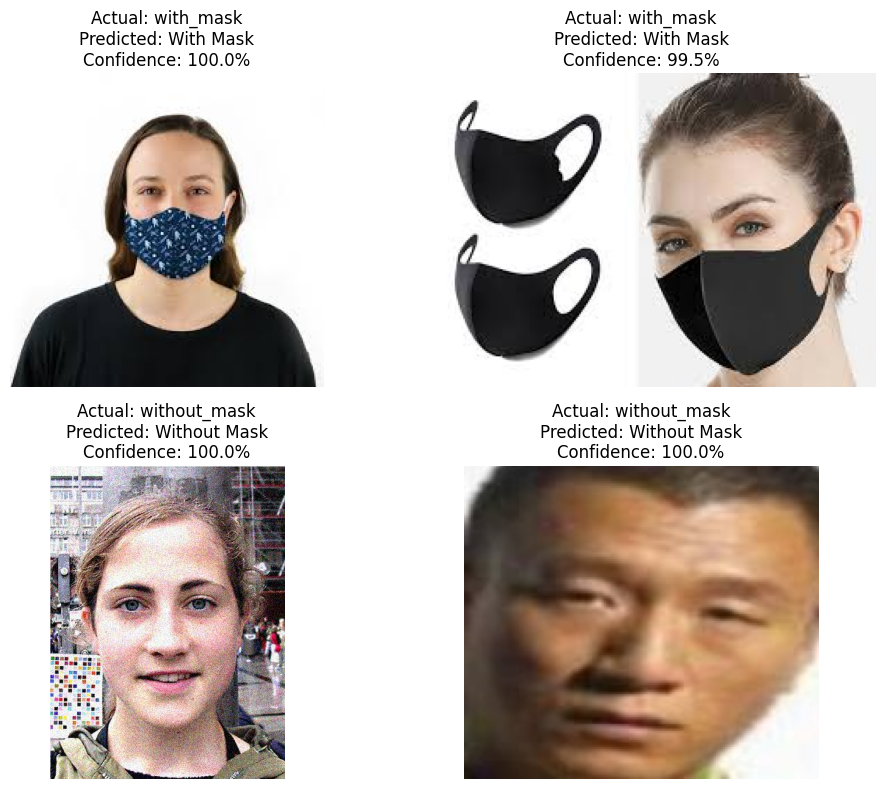

In [8]:
def predict_mask(img_path):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (100, 100))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)
    
    prediction = model.predict(img_input, verbose=0)
    
    # FIXED: with_mask=0, without_mask=1
    label = "With Mask" if prediction[0][0] < 0.5 else "Without Mask"
    confidence = (1 - prediction[0][0]) * 100 if prediction[0][0] < 0.5 else prediction[0][0] * 100
    
    return label, confidence, img

# Test again
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, category in enumerate(["with_mask", "with_mask", "without_mask", "without_mask"]):
    path = os.path.join("dataset", category)
    img_name = random.choice(os.listdir(path))
    img_path = os.path.join(path, img_name)
    
    label, confidence, img = predict_mask(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"Actual: {category}\nPredicted: {label}\nConfidence: {confidence:.1f}%")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png')
plt.show()

In [9]:
# Debug cell - see raw numbers
for category in ["with_mask", "without_mask"]:
    path = os.path.join("dataset", category)
    # pick first 3 images
    images = os.listdir(path)[:3]
    
    print(f"\n--- {category} ---")
    for img_name in images:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read: {img_name}")
            continue
        img_resized = cv2.resize(img, (100, 100))
        img_normalized = img_resized / 255.0
        img_input = np.expand_dims(img_normalized, axis=0)
        prediction = model.predict(img_input, verbose=0)
        print(f"{img_name}: raw prediction = {prediction[0][0]:.6f}")


--- with_mask ---
with_mask_1.jpg: raw prediction = 0.000097
with_mask_10.jpg: raw prediction = 0.059262
with_mask_100.jpg: raw prediction = 0.009013

--- without_mask ---
without_mask_1.jpg: raw prediction = 0.999254
without_mask_10.jpg: raw prediction = 0.999996
without_mask_100.jpg: raw prediction = 0.999890
